In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import sys
from umap import UMAP
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
df = pd.read_csv('Export Data-data-as-joinbyfield-2025-09-27 12_43_54.csv')
df.replace('undefined', np.nan, inplace=True)

In [17]:
df

,Time,frame_classify_latency,frame_classify_latency.1,frame_classify_latency.2,frame_classify_latency.3,frame_classify_latency.4,frame_classify_latency.5,frames_sent_total_camera,frames_sent_total_detector,frames_sent_total_detector.1,...,group3-node2_cpu_5,group3-node1_cpu_5,group3-node2_cpu_6,group3-node1_cpu_6,group3-node2_cpu_7,group3-node1_cpu_7,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory
0,1758883380000,NaN,NaN,24.969548001536168,NaN,NaN,NaN,1803,NaN,NaN,...,0.038814,0.285593,0.040000,0.278475,0.044576,0.283559,8201.257680,13529.253509,11096.091433,8879.811970
1,1758883440000,NaN,NaN,95.4173579957569,NaN,NaN,NaN,1983,NaN,NaN,...,0.002034,0.277458,0.003729,0.283729,0.002712,0.267119,8180.899364,15032.282309,5123.065281,10194.919293
2,1758883500000,NaN,NaN,175.66110799089074,NaN,NaN,NaN,2163,NaN,NaN,...,0.003390,0.381186,0.004237,0.403220,0.003898,0.340169,5112.616327,14530.952331,4268.910818,9536.921279
3,1758883560000,NaN,NaN,132.69305499852635,NaN,NaN,NaN,2343,NaN,NaN,...,0.002881,0.413729,0.004407,0.462373,0.003559,0.373390,4090.445312,14529.869836,2134.712990,9535.741459
4,1758883620000,NaN,NaN,69.02029100456275,NaN,NaN,NaN,2523,NaN,NaN,...,0.004237,0.293898,0.003390,0.312373,0.003559,0.295763,2556.659494,14530.233713,2134.782044,9536.005561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,1758969540000,NaN,NaN,NaN,27.538457012269646,NaN,NaN,27951,NaN,NaN,...,0.001356,0.278136,0.003220,0.277458,0.002203,0.271186,3587.742452,16524.842492,2773.321372,10812.713255
1437,1758969600000,NaN,NaN,NaN,72.67896700068377,NaN,NaN,28131,NaN,NaN,...,0.002034,0.293574,0.004746,0.303914,0.002881,0.270014,2050.266221,14521.471232,1584.882018,9501.409566
1438,1758969660000,NaN,NaN,NaN,186.49064301280305,NaN,NaN,28311,NaN,NaN,...,0.002373,0.324237,0.003898,0.328305,0.002034,0.339831,2562.806541,15521.999669,1981.073954,10155.933395
1439,1758969720000,NaN,NaN,NaN,111.13071200088598,NaN,NaN,28491,NaN,NaN,...,0.002881,0.445254,0.002712,0.476102,0.002373,0.406780,4101.045418,15521.846266,3170.270657,10155.708289


In [18]:
col = 'group3-node1_free_memory'

if col not in df.columns:
    raise KeyError(f"Columna '{col}' no encontrada en df")

mask = df[col].notna()
if not mask.any():
    print(f"No se encontraron valores no nulos en '{col}'. No se realiza truncado.")
else:
    first_label = mask.idxmax()  
    df = df.loc[first_label:].reset_index(drop=True)
    if 'Time' in df.columns:
        cols_to_num = df.columns.drop('Time')
    else:
        cols_to_num = df.columns
    df_num = df[cols_to_num].apply(pd.to_numeric, errors='coerce')
    print(f"Dataframe truncado. Nueva longitud: {len(df)}. Inicio en índice original: {first_label}")

Dataframe truncado. Nueva longitud: 1441. Inicio en índice original: 0


In [19]:
df_num['not_down'] = df_num['group3-node1_free_memory'].notna().astype(int)

df_num['not_down'].value_counts(dropna=False)

not_down
1    1441
Name: count, dtype: int64

In [20]:
lista_frame_latency = []
for col in df_num.columns:
    if "frame_classify_latency" in col:
        df_num[col].replace(np.nan, 0, inplace=True)
        lista_frame_latency.append(col)

C:\Users\halol\AppData\Local\Temp\ipykernel_26272\4275551163.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[col].replace(np.nan, 0, inplace=True)


In [21]:
df_num["lat_aggrup"] = df_num[lista_frame_latency].sum(axis=1)
df_num["lat_aggrup"] = df_num["lat_aggrup"]/2

In [ ]:
df_num.drop(columns=lista_frame_latency, inplace=True)

In [ ]:
frames_sent_total_detector = []
for col in df_num.columns:
    if "frames_sent_total_detector" in col:
        df_num[col].replace(np.nan, 0, inplace=True)
        frames_sent_total_detector.append(col)

C:\Users\halol\AppData\Local\Temp\ipykernel_6760\1607117732.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[col].replace(np.nan, 0, inplace=True)


In [ ]:
df_num["frame_aggrup"] = df_num[frames_sent_total_detector].sum(axis=1)

In [ ]:
df_num.drop(columns=frames_sent_total_detector, inplace=True)

In [ ]:
# Find columns with identical data
duplicated_columns = set()

# Get the numerical columns to compare
columns = df_num.columns

# Compare each column with every other column
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        # Check if columns have identical values
        if df_num[columns[i]].equals(df_num[columns[j]]):
            # Keep the first column, mark the second one as duplicate
            duplicated_columns.add(columns[j])

# Remove duplicate columns
df_num_no_dupes = df_num.drop(columns=list(duplicated_columns))

# Print information about removed columns
print(f"Removed {len(duplicated_columns)} duplicate columns.")
print(f"Original shape: {df_num.shape}, New shape: {df_num_no_dupes.shape}")

# Display the removed columns
if duplicated_columns:
    print("\nRemoved columns:")
    for col in sorted(duplicated_columns):
        print(f"- {col}")

Removed 0 duplicate columns.
Original shape: (1441, 48), New shape: (1441, 48)


In [ ]:
people_box_count = []
for col in df_num.columns:
    if "people_box_count" in col:
        df_num[col].replace(np.nan, 0, inplace=True)
        people_box_count.append(col)

C:\Users\halol\AppData\Local\Temp\ipykernel_6760\1342634666.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[col].replace(np.nan, 0, inplace=True)


In [ ]:
df_num["people_box_agg"] = df_num[people_box_count].sum(axis=1) # reparar

In [ ]:
df_num.drop(columns=people_box_count, inplace=True)

In [ ]:
df_num

,frames_sent_total_camera,detector_frame_latency,detector_frame_latency.1,detector_frame_latency.2,detector_frame_latency.3,detector_frame_latency.4,detector_frame_latency.5,classifier_frames_processed_total,classifier_frames_processed_total.1,classifier_frames_processed_total.2,...,group3-node2_cpu_7,group3-node1_cpu_7,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down,lat_aggrup,frame_aggrup,people_box_agg
0,1803.0,NaN,NaN,NaN,76.638460,NaN,NaN,NaN,NaN,1722.0,...,0.044576,0.283559,8201.257680,13529.253509,11096.091433,8879.811970,1,24.969548,1793.0,1.0
1,1983.0,NaN,NaN,NaN,81.341982,NaN,NaN,NaN,NaN,1880.0,...,0.002712,0.267119,8180.899364,15032.282309,5123.065281,10194.919293,1,95.417358,1973.0,4.0
2,2163.0,NaN,NaN,NaN,59.633493,NaN,NaN,NaN,NaN,2057.0,...,0.003898,0.340169,5112.616327,14530.952331,4268.910818,9536.921279,1,175.661108,2153.0,8.0
3,2343.0,NaN,NaN,NaN,78.132153,NaN,NaN,NaN,NaN,2236.0,...,0.003559,0.373390,4090.445312,14529.869836,2134.712990,9535.741459,1,132.693055,2333.0,5.0
4,2523.0,NaN,NaN,NaN,75.895309,NaN,NaN,NaN,NaN,2386.0,...,0.003559,0.295763,2556.659494,14530.233713,2134.782044,9536.005561,1,69.020291,2513.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,27951.0,NaN,NaN,81.406116,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002203,0.271186,3587.742452,16524.842492,2773.321372,10812.713255,1,27.538457,34671.0,1.0
1437,28131.0,NaN,NaN,59.777737,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002881,0.270014,2050.266221,14521.471232,1584.882018,9501.409566,1,72.678967,34851.0,3.0
1438,28311.0,NaN,NaN,66.218376,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002034,0.339831,2562.806541,15521.999669,1981.073954,10155.933395,1,186.490643,35031.0,8.0
1439,28491.0,NaN,NaN,82.090139,NaN,NaN,NaN,NaN,NaN,NaN,...,0.002373,0.406780,4101.045418,15521.846266,3170.270657,10155.708289,1,111.130712,35211.0,7.0


In [ ]:
detector_frame_latency = []
for col in df_num.columns:
    if "detector_frame_latency" in col:
        df_num[col].replace(np.nan, 0, inplace=True)
        detector_frame_latency.append(col)

C:\Users\halol\AppData\Local\Temp\ipykernel_6760\4159734598.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[col].replace(np.nan, 0, inplace=True)


In [ ]:
df_num["detector_frame_agg"] = df_num[detector_frame_latency].sum(axis=1)

In [ ]:
df_num.drop(columns=detector_frame_latency, inplace=True)

In [ ]:
df_num

,frames_sent_total_camera,classifier_frames_processed_total,classifier_frames_processed_total.1,classifier_frames_processed_total.2,classifier_frames_processed_total.3,classifier_frames_processed_total.4,classifier_frames_processed_total.5,object_classify_latency,object_classify_latency.1,object_classify_latency.2,...,group3-node1_cpu_7,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down,lat_aggrup,frame_aggrup,people_box_agg,detector_frame_agg
0,1803.0,NaN,NaN,1722.0,NaN,NaN,NaN,NaN,NaN,21.756583,...,0.283559,8201.257680,13529.253509,11096.091433,8879.811970,1,24.969548,1793.0,1.0,76.638460
1,1983.0,NaN,NaN,1880.0,NaN,NaN,NaN,NaN,NaN,18.633191,...,0.267119,8180.899364,15032.282309,5123.065281,10194.919293,1,95.417358,1973.0,4.0,81.341982
2,2163.0,NaN,NaN,2057.0,NaN,NaN,NaN,NaN,NaN,18.658219,...,0.340169,5112.616327,14530.952331,4268.910818,9536.921279,1,175.661108,2153.0,8.0,59.633493
3,2343.0,NaN,NaN,2236.0,NaN,NaN,NaN,NaN,NaN,18.946203,...,0.373390,4090.445312,14529.869836,2134.712990,9535.741459,1,132.693055,2333.0,5.0,78.132153
4,2523.0,NaN,NaN,2386.0,NaN,NaN,NaN,NaN,NaN,22.683517,...,0.295763,2556.659494,14530.233713,2134.782044,9536.005561,1,69.020291,2513.0,3.0,75.895309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,27951.0,NaN,NaN,NaN,33787.0,NaN,NaN,NaN,NaN,NaN,...,0.271186,3587.742452,16524.842492,2773.321372,10812.713255,1,27.538457,34671.0,1.0,81.406116
1437,28131.0,NaN,NaN,NaN,33941.0,NaN,NaN,NaN,NaN,NaN,...,0.270014,2050.266221,14521.471232,1584.882018,9501.409566,1,72.678967,34851.0,3.0,59.777737
1438,28311.0,NaN,NaN,NaN,34113.0,NaN,NaN,NaN,NaN,NaN,...,0.339831,2562.806541,15521.999669,1981.073954,10155.933395,1,186.490643,35031.0,8.0,66.218376
1439,28491.0,NaN,NaN,NaN,34293.0,NaN,NaN,NaN,NaN,NaN,...,0.406780,4101.045418,15521.846266,3170.270657,10155.708289,1,111.130712,35211.0,7.0,82.090139


In [ ]:
classifier_frames_processed_total = []
for col in df_num.columns:
    if "classifier_frames_processed_total" in col:
        df_num[col].replace(np.nan, 0, inplace=True)
        classifier_frames_processed_total.append(col)

C:\Users\halol\AppData\Local\Temp\ipykernel_6760\2844411796.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[col].replace(np.nan, 0, inplace=True)


In [ ]:
df_num["classifier_frames_p_agg"] = df_num[classifier_frames_processed_total].sum(axis=1)

In [ ]:
df_num.drop(columns=classifier_frames_processed_total, inplace=True)

In [ ]:
df_num

,frames_sent_total_camera,object_classify_latency,object_classify_latency.1,object_classify_latency.2,object_classify_latency.3,object_classify_latency.4,object_classify_latency.5,group3-node2_cpu_0,group3-node1_cpu_0,group3-node2_cpu_1,...,group3-node2_available_memory,group3-node1_available_memory,group3-node2_free_memory,group3-node1_free_memory,not_down,lat_aggrup,frame_aggrup,people_box_agg,detector_frame_agg,classifier_frames_p_agg
0,1803.0,NaN,NaN,21.756583,NaN,NaN,NaN,0.037288,0.271186,0.038136,...,8201.257680,13529.253509,11096.091433,8879.811970,1,24.969548,1793.0,1.0,76.638460,1722.0
1,1983.0,NaN,NaN,18.633191,NaN,NaN,NaN,0.003729,0.267627,0.002881,...,8180.899364,15032.282309,5123.065281,10194.919293,1,95.417358,1973.0,4.0,81.341982,1880.0
2,2163.0,NaN,NaN,18.658219,NaN,NaN,NaN,0.004407,0.377458,0.004068,...,5112.616327,14530.952331,4268.910818,9536.921279,1,175.661108,2153.0,8.0,59.633493,2057.0
3,2343.0,NaN,NaN,18.946203,NaN,NaN,NaN,0.003051,0.407288,0.003390,...,4090.445312,14529.869836,2134.712990,9535.741459,1,132.693055,2333.0,5.0,78.132153,2236.0
4,2523.0,NaN,NaN,22.683517,NaN,NaN,NaN,0.003898,0.290678,0.003729,...,2556.659494,14530.233713,2134.782044,9536.005561,1,69.020291,2513.0,3.0,75.895309,2386.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,27951.0,NaN,NaN,NaN,22.379504,NaN,NaN,0.004407,0.278136,0.002203,...,3587.742452,16524.842492,2773.321372,10812.713255,1,27.538457,34671.0,1.0,81.406116,33787.0
1437,28131.0,NaN,NaN,NaN,19.460462,NaN,NaN,0.003051,0.297473,0.003051,...,2050.266221,14521.471232,1584.882018,9501.409566,1,72.678967,34851.0,3.0,59.777737,33941.0
1438,28311.0,NaN,NaN,NaN,19.114951,NaN,NaN,0.003559,0.340847,0.003051,...,2562.806541,15521.999669,1981.073954,10155.933395,1,186.490643,35031.0,8.0,66.218376,34113.0
1439,28491.0,NaN,NaN,NaN,18.733717,NaN,NaN,0.002881,0.454576,0.002373,...,4101.045418,15521.846266,3170.270657,10155.708289,1,111.130712,35211.0,7.0,82.090139,34293.0


In [ ]:
object_classify_latency = []
for col in df_num.columns:
    if "object_classify_latency" in col:
        df_num[col].replace(np.nan, 0, inplace=True)
        object_classify_latency.append(col)

C:\Users\halol\AppData\Local\Temp\ipykernel_6760\540720760.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_num[col].replace(np.nan, 0, inplace=True)


In [ ]:
df_num["object_classify_agg"] = df_num[object_classify_latency].sum(axis=1)

In [ ]:
df_num.drop(columns=object_classify_latency, inplace=True)

In [ ]:
node2_columns = []
for col in df_num.columns:
    if "node2" in col:
        node2_columns.append(col)
df_num.drop(columns=node2_columns, inplace=True)

In [ ]:
df_num.to_pickle("data_cleaned.pkl")

In [ ]:
df_num["Time"] = df["Time"]

In [ ]:
df_num

,frames_sent_total_camera,group3-node1_cpu_0,group3-node1_cpu_1,group3-node1_cpu_2,group3-node1_cpu_3,group3-node1_cpu_4,group3-node1_cpu_5,group3-node1_cpu_6,group3-node1_cpu_7,group3-node1_available_memory,group3-node1_free_memory,not_down,lat_aggrup,frame_aggrup,people_box_agg,detector_frame_agg,classifier_frames_p_agg,object_classify_agg,Time
0,1803.0,0.271186,0.283729,0.274746,0.288644,0.275085,0.285593,0.278475,0.283559,13529.253509,8879.811970,1,24.969548,1793.0,1.0,76.638460,1722.0,21.756583,1758883380000
1,1983.0,0.267627,0.280339,0.270847,0.272203,0.273898,0.277458,0.283729,0.267119,15032.282309,10194.919293,1,95.417358,1973.0,4.0,81.341982,1880.0,18.633191,1758883440000
2,2163.0,0.377458,0.374576,0.369831,0.375085,0.364746,0.381186,0.403220,0.340169,14530.952331,9536.921279,1,175.661108,2153.0,8.0,59.633493,2057.0,18.658219,1758883500000
3,2343.0,0.407288,0.438983,0.415763,0.422034,0.419153,0.413729,0.462373,0.373390,14529.869836,9535.741459,1,132.693055,2333.0,5.0,78.132153,2236.0,18.946203,1758883560000
4,2523.0,0.290678,0.296780,0.316271,0.278136,0.311017,0.293898,0.312373,0.295763,14530.233713,9536.005561,1,69.020291,2513.0,3.0,75.895309,2386.0,22.683517,1758883620000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1436,27951.0,0.278136,0.298136,0.278644,0.300847,0.298305,0.278136,0.277458,0.271186,16524.842492,10812.713255,1,27.538457,34671.0,1.0,81.406116,33787.0,22.379504,1758969540000
1437,28131.0,0.297473,0.284760,0.302727,0.297134,0.300524,0.293574,0.303914,0.270014,14521.471232,9501.409566,1,72.678967,34851.0,3.0,59.777737,33941.0,19.460462,1758969600000
1438,28311.0,0.340847,0.345932,0.345593,0.341186,0.345932,0.324237,0.328305,0.339831,15521.999669,10155.933395,1,186.490643,35031.0,8.0,66.218376,34113.0,19.114951,1758969660000
1439,28491.0,0.454576,0.418983,0.435085,0.450339,0.430339,0.445254,0.476102,0.406780,15521.846266,10155.708289,1,111.130712,35211.0,7.0,82.090139,34293.0,18.733717,1758969720000


In [ ]:
df_num.to_pickle("data_cleaned.pkl")

In [ ]:
# Check target variable distribution
print("Distribution of 'not_down':")
print(df_num['not_down'].value_counts())
print(f"Percentage of class 1: {df_num['not_down'].mean() * 100:.2f}%")

# Split data into features and target
X = df_num.drop(['not_down', 'Time'], axis=1)
y = df_num['not_down']

# Train-test split (using stratified sampling to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluate model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# map class numeric labels to readable names (0 -> Down, 1 -> Not Down)
labels_order = list(rf_model.classes_)
label_name_map = {0: 'Down', 1: 'Not Down'}
target_names = [label_name_map.get(lbl, str(lbl)) for lbl in labels_order]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

# Plot confusion matrix with correct class names
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Feature importance
feature_imp = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Plot top 20 features
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20))
plt.title('Top 20 Most Important Features')
plt.tight_layout()
plt.show()

# Print the top 15 features
print("\nTop 15 most important features:")
print(feature_imp.head(15))

# Identify the most important features (those with importance > 1%)
important_features = feature_imp[feature_imp['Importance'] > 0.01]['Feature'].tolist()
print(f"\nIdentified {len(important_features)} important features (>1% importance):")
print(important_features)

Distribution of 'not_down':
not_down
1    1441
Name: count, dtype: int64
Percentage of class 1: 100.00%


IndexError: index 1 is out of bounds for axis 1 with size 1

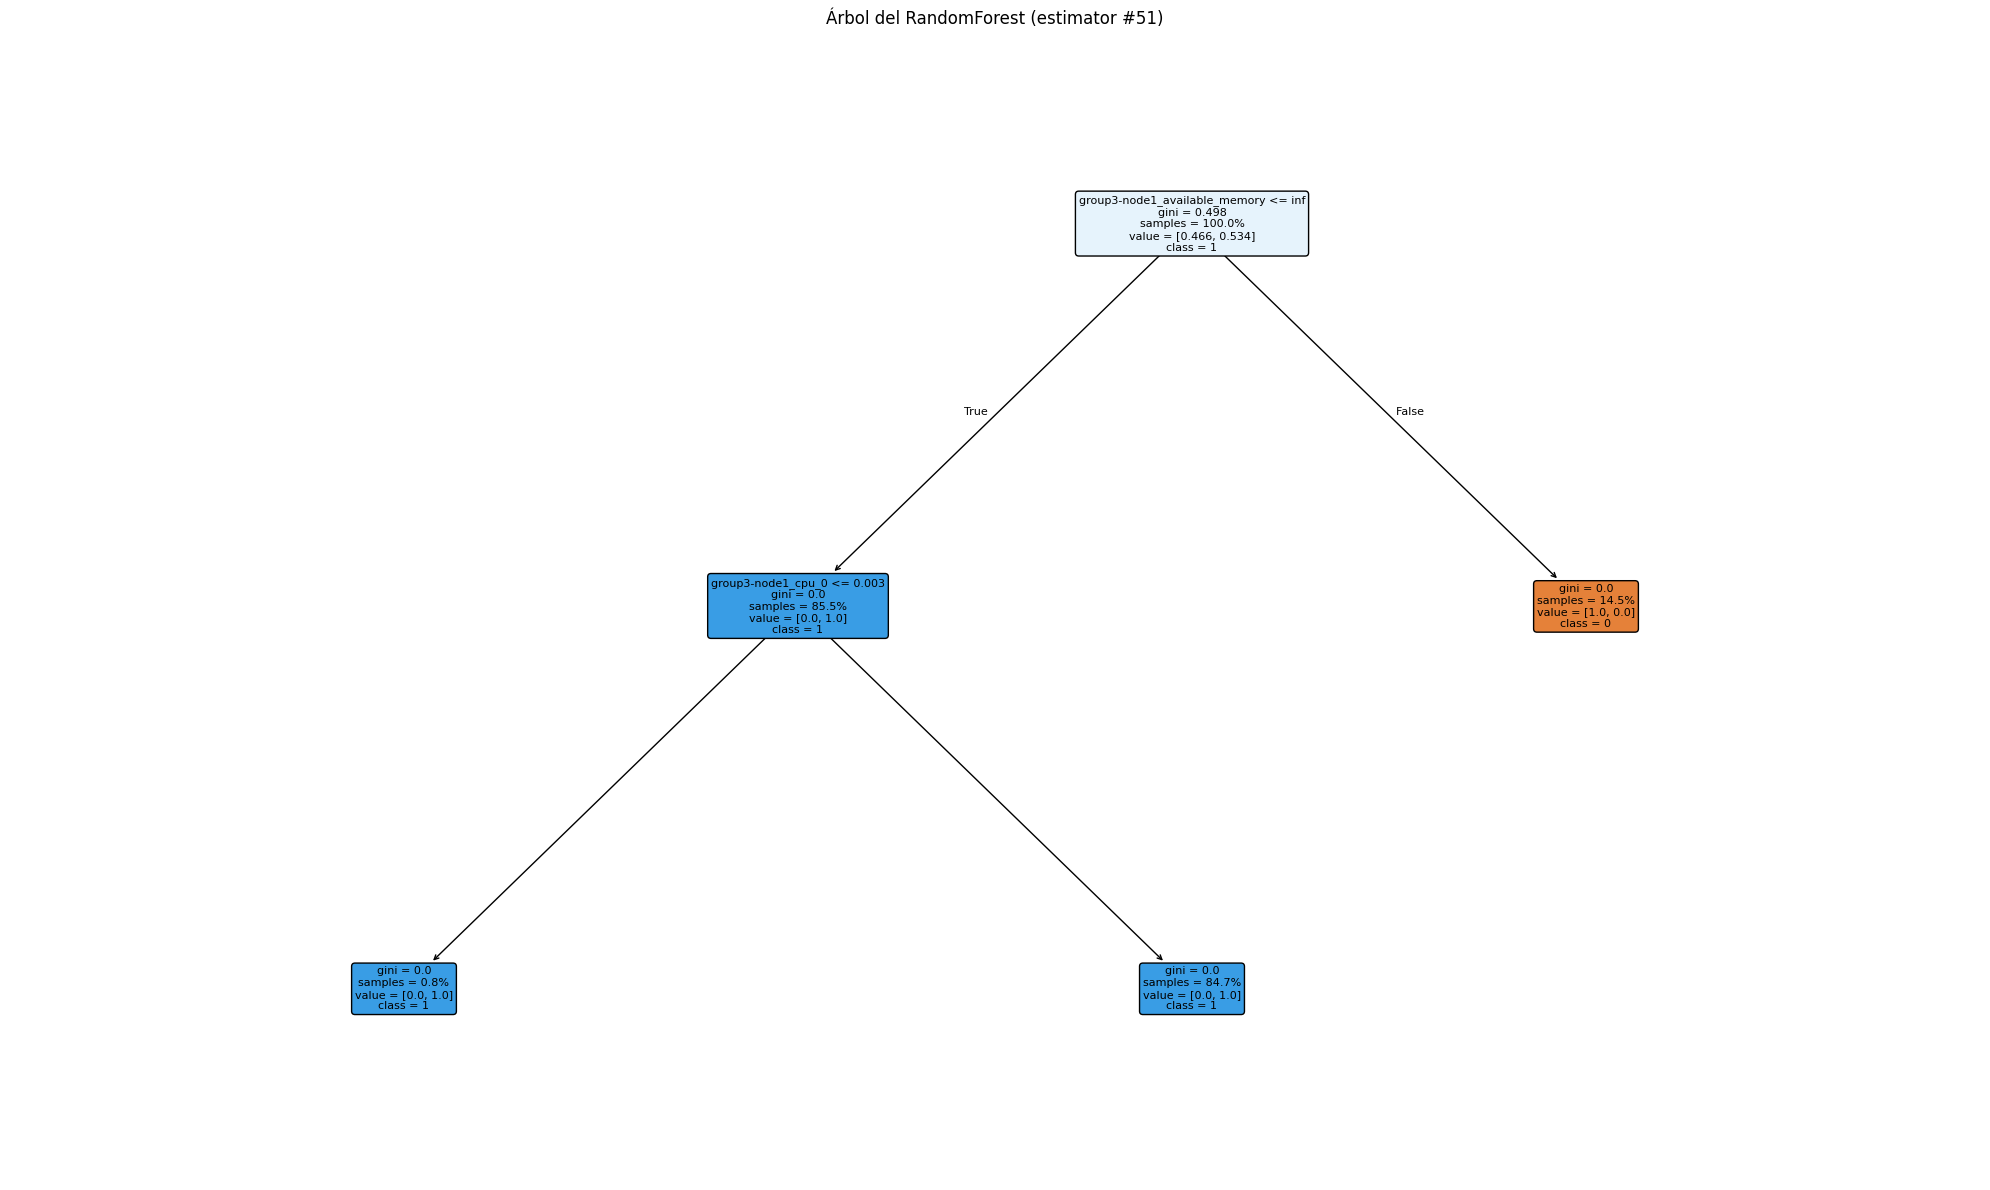

In [ ]:
from sklearn import tree

import matplotlib.pyplot as plt

# elegir índice del árbol (usa la variable `i` si existe, sino 0)
try:
    est_idx = int(i)
except NameError:
    est_idx = 0
except Exception:
    est_idx = 0

if not hasattr(rf_model, "estimators_"):
    raise ValueError("rf_model no contiene estimors_. Entrena el modelo antes de mostrar un árbol.")

if est_idx < 0 or est_idx >= len(rf_model.estimators_):
    raise IndexError(f"est_idx {est_idx} fuera de rango (0..{len(rf_model.estimators_)-1})")

est = rf_model.estimators_[est_idx]

plt.figure(figsize=(20, 12))
tree.plot_tree(
    est,
    feature_names=X_train.columns if 'X_train' in globals() else None,
    class_names=[str(c) for c in rf_model.classes_],
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=8
)
plt.title(f"Árbol del RandomForest (estimator #{est_idx})")
plt.tight_layout()
plt.show()

In [ ]:
# 1. Asegurar que los datos estén ordenados cronológicamente
df_sorted = df.sort_values('Time').reset_index(drop=True)
df_num_sorted = df_num.sort_values('Time') if 'Time' in df_num.columns else df_num
df_num_sorted.drop(columns=['Time'], inplace=True)
# 2. Crear la nueva variable objetivo con lag (shift negativo)
# Por ejemplo, para predecir el estado 4 puntos de tiempo antes:
lag_steps = 1  # Ajusta este valor según el lag temporal deseado
df_num_sorted['future_down'] = df_num_sorted['not_down'].shift(-lag_steps)

# 3. Eliminar las filas donde no tenemos el valor futuro (al final del dataset)
df_num_sorted.dropna(subset=['future_down'], inplace=True)

# 4. Preparar datos para entrenamiento
X = df_num_sorted.drop(['not_down', 'future_down'], axis=1)  # Usar datos actuales
y = df_num_sorted['future_down']  # Predecir estado futuro

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=None, random_state=42, stratify=y
)

# 6. Entrenar modelo con la nueva variable objetivo
rf_model_predictive = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    class_weight='balanced'
)

rf_model_predictive.fit(X_train, y_train)

# 7. Evaluar el modelo predictivo
y_pred = rf_model_predictive.predict(X_test)
print(f"Accuracy (modelo predictivo con lag {lag_steps}): {accuracy_score(y_test, y_pred):.4f}")

# 8. Mostrar informe de clasificación
label_name_map = {0: f'Down en {lag_steps} unidades', 1: f'Operativo en {lag_steps} unidades'}
target_names = [label_name_map.get(lbl, str(lbl)) for lbl in rf_model_predictive.classes_]
print("\nInforme de clasificación (modelo predictivo):")
print(classification_report(y_test, y_pred, target_names=target_names))

# 9. Analizar características importantes para la predicción anticipada
feature_imp = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model_predictive.feature_importances_
})
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

print("\nTop 15 características para predicción anticipada:")
print(feature_imp.head(15))

NameError: name 'df' is not defined

In [ ]:
df_num_sorted.to_pickle("data_cleaned_to_test.pkl")


Evaluación del Modelo Predictivo (Lag):
Accuracy: 0.9938

Informe de clasificación (modelo predictivo):
                         precision    recall  f1-score   support

     Down en 1 unidades       1.00      0.96      0.98        52
Operativo en 1 unidades       0.99      1.00      1.00       271

               accuracy                           0.99       323
              macro avg       1.00      0.98      0.99       323
           weighted avg       0.99      0.99      0.99       323



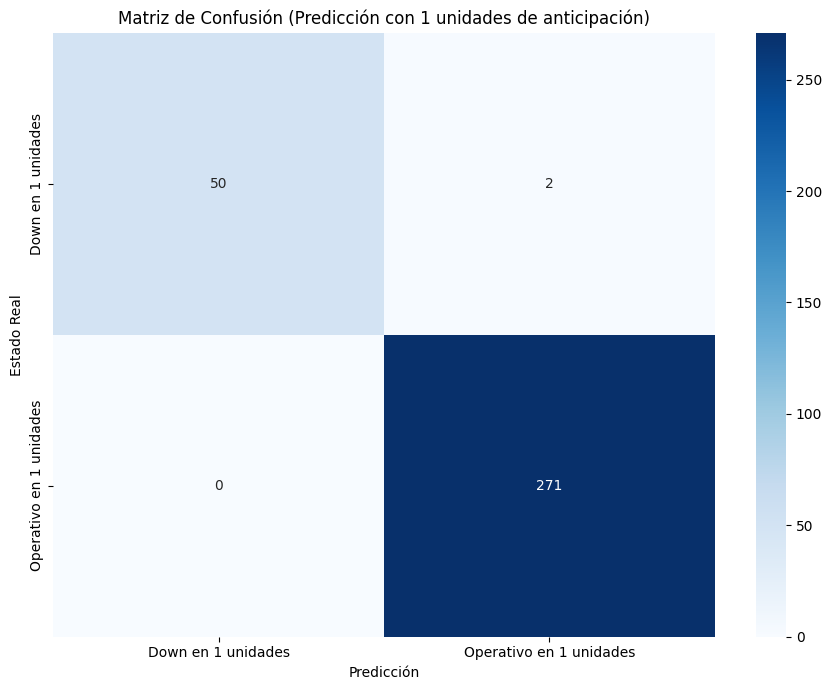

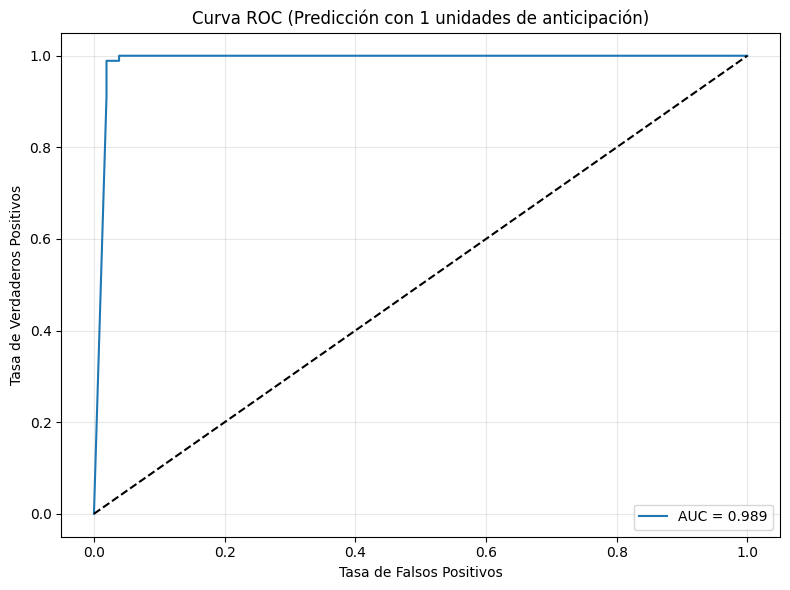

C:\Users\halol\AppData\Local\Temp\ipykernel_18956\3290682894.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')


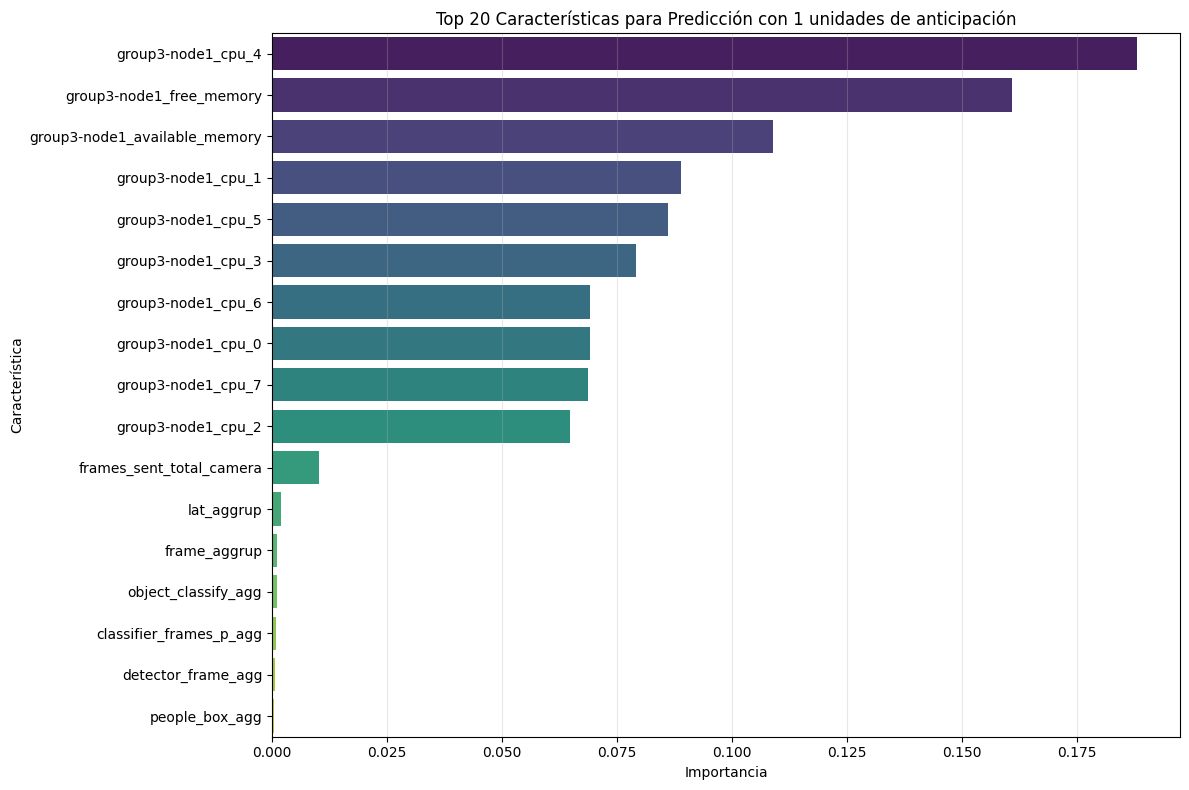


Top 15 características para predicción con 1 unidades de anticipación:
                          Feature  Importance
0              group3-node1_cpu_4    0.187999
1        group3-node1_free_memory    0.160895
2   group3-node1_available_memory    0.108938
3              group3-node1_cpu_1    0.088956
4              group3-node1_cpu_5    0.086067
5              group3-node1_cpu_3    0.079143
6              group3-node1_cpu_6    0.069233
7              group3-node1_cpu_0    0.069076
8              group3-node1_cpu_7    0.068603
9              group3-node1_cpu_2    0.064826
10       frames_sent_total_camera    0.010195
11                     lat_aggrup    0.001886
12                   frame_aggrup    0.001119
13            object_classify_agg    0.001079
14        classifier_frames_p_agg    0.000951

Identificadas 11 características importantes (>1% importancia):
['group3-node1_cpu_4', 'group3-node1_free_memory', 'group3-node1_available_memory', 'group3-node1_cpu_1', 'group3-node1_cpu_5',

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Time


In [ ]:
# Crear probabilidades de predicción (necesarias para ROC)
y_pred = rf_model_predictive.predict(X_test)
y_prob = rf_model_predictive.predict_proba(X_test)[:, 1]  # Probabilidad de la clase positiva

# Evaluación del modelo
print("\nEvaluación del Modelo Predictivo (Lag):")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Definir etiquetas con información de lag
labels_order = list(rf_model_predictive.classes_)
label_name_map = {0: f'Down en {lag_steps} unidades', 1: f'Operativo en {lag_steps} unidades'}
target_names = [label_name_map.get(lbl, str(lbl)) for lbl in labels_order]

# Reporte de clasificación
print("\nInforme de clasificación (modelo predictivo):")
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicción')
plt.ylabel('Estado Real')
plt.title(f'Matriz de Confusión (Predicción con {lag_steps} unidades de anticipación)')
plt.tight_layout()
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title(f'Curva ROC (Predicción con {lag_steps} unidades de anticipación)')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Importancia de características
feature_imp = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model_predictive.feature_importances_
})
feature_imp = feature_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

# Visualizar top 20 características
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_imp.head(20), palette='viridis')
plt.title(f'Top 20 Características para Predicción con {lag_steps} unidades de anticipación')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar top 15 características en texto
print(f"\nTop 15 características para predicción con {lag_steps} unidades de anticipación:")
print(feature_imp.head(15))

# Identificar características importantes (>1%)
important_features = feature_imp[feature_imp['Importance'] > 0.01]['Feature'].tolist()
print(f"\nIdentificadas {len(important_features)} características importantes (>1% importancia):")
print(important_features)

# ADICIONAL: Visualización de predicciones vs. valores reales en la serie temporal
if 'Time' in df_num_sorted.columns:
    # Crear predicciones para todo el conjunto
    all_X = df_num_sorted.drop(['not_down', 'future_down'], axis=1)
    all_predictions = rf_model_predictive.predict(all_X)
    
    # Dataframe para visualización
    df_vis = pd.DataFrame({
        'Time': pd.to_datetime(df_num_sorted['Time'], unit='ms') if not pd.api.types.is_datetime64_any_dtype(df_num_sorted['Time']) else df_num_sorted['Time'],
        'Real': df_num_sorted['future_down'],
        'Predicción': all_predictions
    })
    
    plt.figure(figsize=(14, 6))
    
    # Índices donde hay errores
    errores = df_vis['Real'] != df_vis['Predicción']
    aciertos = ~errores
    
    # Graficar puntos acertados y errores con colores distintos
    plt.scatter(df_vis.loc[aciertos, 'Time'], df_vis.loc[aciertos, 'Real'], 
                c='green', label='Aciertos', alpha=0.6, s=30, marker='o')
    plt.scatter(df_vis.loc[errores, 'Time'], df_vis.loc[errores, 'Real'], 
                c='red', label='Errores de predicción', alpha=0.8, s=50, marker='x')
    
    plt.yticks([0, 1], [label_name_map[0], label_name_map[1]])
    plt.title(f'Predicciones vs. Estado Real (Lag={lag_steps})')
    plt.xlabel('Tiempo')
    plt.ylabel('Estado del Sistema')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Mostrar tasa de acierto global
    print(f"Tasa de acierto global: {(~errores).mean()*100:.2f}%")

In [ ]:
import joblib
import pickle

# Export the predictive model
joblib.dump(rf_model_predictive, 'rf_model_predictive.joblib')

# Also export the important features for reference
with open('important_features.pkl', 'wb') as f:
    pickle.dump(important_features, f)

print("Model exported successfully to 'rf_model_predictive.joblib'")
print(f"Important features saved to 'important_features.pkl' ({len(important_features)} features)")

Model exported successfully to 'rf_model_predictive.joblib'
Important features saved to 'important_features.pkl' (10 features)


In [ ]:
import joblib
import pickle
import pandas as pd
import numpy as np

# Load the saved model
loaded_model = joblib.load('rf_model_predictive.joblib')

# Load the important features list
with open('important_features.pkl', 'rb') as f:
    important_features = pickle.load(f)
    
print(f"Model loaded successfully from 'rf_model_predictive.joblib'")
print(f"Loaded {len(important_features)} important features:")
print(important_features)

# Demonstrate how to use the model for prediction
def prepare_data_for_prediction(df_sample):
    """
    Prepare data for prediction, ensuring it has all required features.
    
    Parameters:
    -----------
    df_sample : pandas.DataFrame
        Sample dataframe with system metrics
        
    Returns:
    --------
    pandas.DataFrame
        Processed dataframe ready for prediction
    """
    # Ensure all required columns are present
    missing_cols = set(important_features) - set(df_sample.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns: {missing_cols}")
    
    # Return only the important features in the correct order
    return df_sample[important_features]

# Example: How to use the model with new data
print("\nExample: Using the model for prediction")
print("--------------------------------------")
print("1. Prepare your data (ensure it contains all required features)")
print("2. Use the model's predict() method to get predictions")
print("3. Use predict_proba() to get probability estimates\n")

# Create a simple example with dummy data
print("Sample usage with dummy data:")
# Create dummy data with all required features that the model expects
# We need to use X.columns (which has all features used for training) instead of just important_features
dummy_data = pd.DataFrame({
    feature: [df_num_sorted[feature].mean()] for feature in X.columns
})
print(f"\nSample data shape: {dummy_data.shape}")

# Make predictions
predictions = loaded_model.predict(dummy_data)
probabilities = loaded_model.predict_proba(dummy_data)[:, 1]  # Probability of class 1

# Show results
status = "Operational" if predictions[0] == 1 else "Down"
print(f"Prediction: System will be {status} with {probabilities[0]:.2%} probability")

Model loaded successfully from 'rf_model_predictive.joblib'
Loaded 10 important features:
['group3-node1_free_memory', 'group3-node1_available_memory', 'group3-node1_cpu_0', 'group3-node1_cpu_1', 'group3-node1_cpu_7', 'group3-node1_cpu_2', 'group3-node1_cpu_3', 'group3-node1_cpu_5', 'group3-node1_cpu_4', 'group3-node1_cpu_6']

Example: Using the model for prediction
--------------------------------------
1. Prepare your data (ensure it contains all required features)
2. Use the model's predict() method to get predictions
3. Use predict_proba() to get probability estimates

Sample usage with dummy data:

Sample data shape: (1, 18)
Prediction: System will be Operational with 100.00% probability


In [ ]:
dummy_data

,group3-node1_free_memory,group3-node1_available_memory,group3-node1_cpu_0,group3-node1_cpu_1,group3-node1_cpu_7,group3-node1_cpu_2,group3-node1_cpu_3,group3-node1_cpu_5,group3-node1_cpu_4,group3-node1_cpu_6
0,9695.224822,14770.723999,0.347203,0.355653,0.339766,0.351943,0.351745,0.350041,0.354953,0.360539
